# 🧠 Supervised Contrastive Learning (SupCon)

**Part I · CNN Architectures & Visual Representations**

---

## 👤 Instructor

**Ing. Jesús Alan Hernández Galván**

📫 alanhernandezgalvan@icloud.com
🌐 [https://unlikeghost.github.io/](https://unlikeghost.github.io/)

---

## 🗺️ Progreso del curso

1. **CNN: The Feature Extractor** 📍
2. Embedding Architectures & Similarity Learning
3. The SupCon Pipeline (Scalability & Transfer)

---

## 🎯 Objetivo del módulo

Implementar y analizar una **CNN básica**

El enfoque está en entender cómo las capas convolucionales transforman la información visual en representaciones que pueden reutilizarse en tareas posteriores.

# 🧩 Construyendo una CNN básica

In [1]:
import sys

def check_environment():
    if 'google.colab' in sys.modules:
        print("Entorno: Google Colab ☁️")

        from IPython import get_ipython
        ipython = get_ipython()
        if ipython:
            print("Instalando dependencias necesarias...")
            ipython.run_line_magic('pip', 'install --upgrade umap-learn numba')

        return "colab"
    else:
        print("Entorno: Local / Jupyter Notebook")
        return "local"

env = check_environment()

Entorno: Local / Jupyter Notebook


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
import os
import logging

os.environ["TORCH_LOGS"] = "-all"
logging.getLogger("torch._inductor").setLevel(logging.ERROR)

In [4]:
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path = os.path.join(project_root, "data")
models_path = os.path.join(project_root, "models")

## Librerias

In [5]:
import umap
import torch
import random
import torchvision

import numpy as np
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

from torchsummary import summary
from sklearn.metrics import confusion_matrix

In [6]:
from src.models import MiniConvNetClassifier
from src.plot_data import show_batch, show_features, plot_latent_space_3d, plot_latent_space_2d
from src.datasets import ClassificationDataset

## 🔒 Semilla para reproducibilidad

In [7]:
seed: int = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

## ⚡ Optimización de Aceleración por Hardware (CUDA/cuDNN)

### 🚀 Verificar uso de GPU (si está disponible)

In [8]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
    )
print(f"Status: System ready on {device}")

Status: System ready on cuda


In [9]:
if device == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.allow_tf32 = True

## 🧪 Implementación

### 📦 Carga y preprocesamiento de datos

In [10]:
batch_size: int = 512

train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(size=(32, 32), scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

val_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

classes: tuple = (
    'plane', 'car', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse',
    'ship', 'truck'
)

In [11]:
test_data = torchvision.datasets.CIFAR10(
    root=data_path,
    train=False,
    download=True,
)

full_train_dataset = torchvision.datasets.CIFAR10(
    root=data_path,
    train=True,
    download=True,
)

# Definimos los tamaños (80% train, 20% val)
train_size = int(len(full_train_dataset) * .8)
val_size = int(len(full_train_dataset) - train_size)

train_size, val_size, len(test_data)

(40000, 10000, 10000)

In [12]:
train_data, val_data = torch.utils.data.random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

In [13]:
train_dataset = ClassificationDataset(
    dataset=train_data,
    transform=train_transform
)
val_dataset = ClassificationDataset(
    dataset=val_data,
    transform=val_transform
)

test_dataset  = ClassificationDataset(
    dataset=test_data,
    transform=val_transform
)

In [14]:
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=6,
    pin_memory=True,
    persistent_workers=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=6,
    persistent_workers=True,
    pin_memory=True
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=6,
    pin_memory=True,
    persistent_workers=True
)

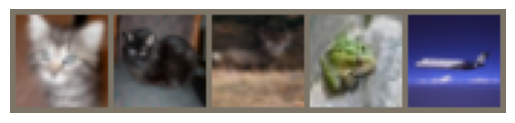

In [15]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images[:5]

show_batch(
    torchvision.utils.make_grid(images),
)

### 🧠 CNN

![CNN](https://discourse.aicrowd.com/uploads/default/original/2X/d/d174aa9014014107e3a4718f3d90180d9b390070.jpeg)

Una red neuronal convolucional (CNN) es un tipo de arquitectura diseñada para
procesar datos con estructura espacial, como imágenes. A diferencia de
una red densa tradicional, no aplana la imagen de entrada — en cambio,
aplica filtros convolucionales que detectan patrones locales como bordes,
texturas y formas, combinándolos progresivamente en representaciones más
abstractas.

Inspiradas en la corteza visual humana, las CNNs procesan la imagen
respetando su estructura espacial: cada capa extrae features más complejas
que la anterior, reduciendo la resolución hasta obtener un vector compacto
que captura la esencia visual de la imagen.

**🎯 Kernel y Stride**

![Stride](https://upload.wikimedia.org/wikipedia/commons/9/92/Convolution_arithmetic_-_Padding_strides_transposed.gif)

El **kernel** (o filtro) es una pequeña matriz que recorre la imagen para detectar patrones locales, como bordes o texturas.
El **stride** define el tamaño del paso con el que este filtro se mueve sobre la imagen: un stride mayor reduce la resolución de salida, mientras que uno menor permite capturar más detalle.

In [16]:
model = MiniConvNetClassifier().to(device)
print(model)
summary(model, input_size=(3, 32, 32))

MiniConvNetClassifier(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (mlp): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=254, bias=True)
    (3): ReLU()
    (4): Linear(in_features=254, out_features=10, bias=True)
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 3

### ⚙️ Proceso de entrenamiento

#### 📉 Optimización (Loss & Optimizer)

![Gradient Descent](https://miro.medium.com/v2/resize:fit:1200/1*STiRp7PW5yIrvYZupZA6nw.gif)

Durante el entrenamiento, el modelo ajusta sus parámetros para minimizar el error.
La **función de pérdida** mide qué tan lejos están las predicciones de los valores reales, mientras que el **optimizador** guía la actualización de los pesos siguiendo la dirección que reduce ese error.

Este proceso, conocido como *gradient descent*, consiste en dar pequeños pasos hacia el mínimo de la función de pérdida en cada iteración.

#### 🚀 Entrenamiento del modelo


In [17]:
num_epochs: int = 30

criterion = nn.CrossEntropyLoss() # función de perdida
optimizer = optim.Adam(model.parameters(), lr=1e-3) # Optimizador

In [18]:
train_loss, val_loss = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):

    # --- FASE DE ENTRENAMIENTO ---
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # Métricas de entrenamiento
        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # --- FASE DE VALIDACIÓN ---
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            # Métricas de validación
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Cálculo de promedios por época
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = train_correct / train_total

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = val_correct / val_total

    # Guardar historial
    train_loss.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)
    val_loss.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")

Epoch [1/30] Train Loss: 1.6013, Acc: 0.4106 | Val Loss: 1.3032, Acc: 0.5313
Epoch [2/30] Train Loss: 1.2420, Acc: 0.5518 | Val Loss: 1.1183, Acc: 0.6035
Epoch [3/30] Train Loss: 1.0867, Acc: 0.6144 | Val Loss: 1.0126, Acc: 0.6426
Epoch [4/30] Train Loss: 1.0090, Acc: 0.6430 | Val Loss: 0.9483, Acc: 0.6650
Epoch [5/30] Train Loss: 0.9406, Acc: 0.6688 | Val Loss: 0.9365, Acc: 0.6745
Epoch [6/30] Train Loss: 0.8795, Acc: 0.6928 | Val Loss: 0.8844, Acc: 0.6893
Epoch [7/30] Train Loss: 0.8286, Acc: 0.7076 | Val Loss: 0.9172, Acc: 0.6837
Epoch [8/30] Train Loss: 0.8018, Acc: 0.7180 | Val Loss: 0.9265, Acc: 0.6809
Epoch [9/30] Train Loss: 0.7648, Acc: 0.7311 | Val Loss: 0.8101, Acc: 0.7203
Epoch [10/30] Train Loss: 0.7403, Acc: 0.7395 | Val Loss: 0.8829, Acc: 0.6993
Epoch [11/30] Train Loss: 0.7076, Acc: 0.7509 | Val Loss: 0.8497, Acc: 0.7099
Epoch [12/30] Train Loss: 0.6764, Acc: 0.7627 | Val Loss: 0.8263, Acc: 0.7218
Epoch [13/30] Train Loss: 0.6570, Acc: 0.7673 | Val Loss: 0.7937, Acc: 0.

In [19]:
torch.save(
    model.state_dict(),
    os.path.join(models_path, "MiniConv_cifar10.pth")
)

### 📊 Métricas de entrenamiento y validación

#### 📊 Entrenamiento

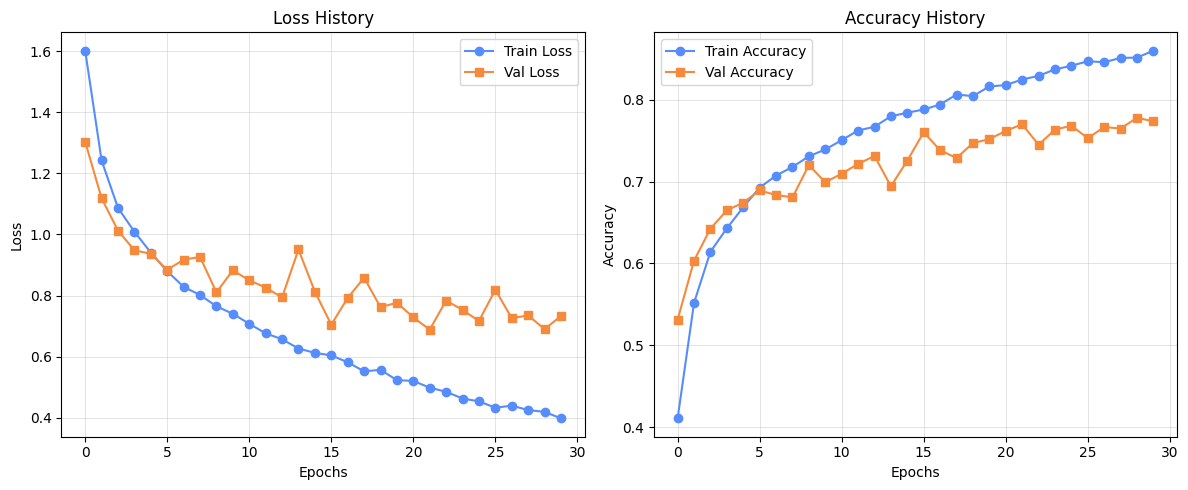

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(train_loss, label='Train Loss', marker='o')
axs[0].plot(val_loss, label='Val Loss', marker='s') # Agregado
axs[0].set_title('Loss History')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(train_acc, label='Train Accuracy', marker='o')
axs[1].plot(val_acc, label='Val Accuracy', marker='s') # Agregado
axs[1].set_title('Accuracy History')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 📊 Validación

In [21]:
model.eval() # Nos aseguramos de que esté en modo evaluación

all_preds = []
all_labels = []

# 1. Pasamos TODAS las imágenes de test por el modelo sin calcular gradientes
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)

        # torch.max nos devuelve el valor máximo y su ÍNDICE (la clase predicha)
        _, predicted = torch.max(outputs, 1)

        # Guardamos las predicciones y las etiquetas reales en la CPU
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

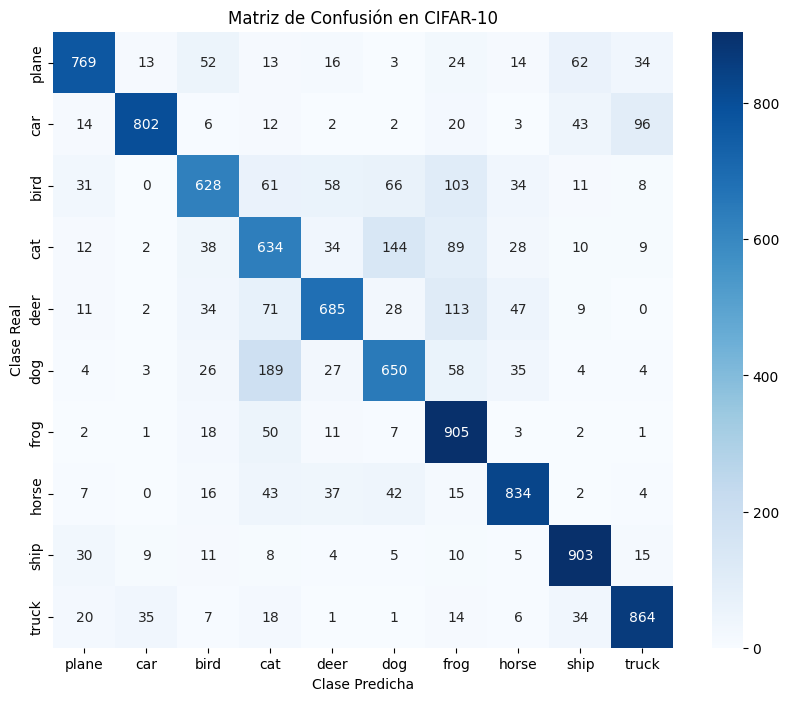

In [22]:
# 2. Creamos la matriz numérica con sklearn
cm = confusion_matrix(all_labels, all_preds)

# 3. Dibujamos la matriz
plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión en CIFAR-10')
plt.show()

### 🔍 Visualización de features

#### 🧩 Feature Maps

In [23]:
model.eval()

images_batch, labels_batch = next(iter(test_loader))
images_batch = images_batch.to(device)

images_batch = images_batch[:5, :, :, :]

with torch.no_grad():
    # Extraer features de la PRIMERA capa (índice 0 es Conv1, índice 1 es ReLU)
    # Pasamos solo por las primeras 2 capas del bloque
    features_conv1 = model.feature_extractor[:2](images_batch)

    # Extraer features de la SEGUNDA capa (índice 3 es Conv2, índice 4 es ReLU)
    # Pasamos por las primeras 5 capas del bloque
    features_conv2 = model.feature_extractor[:5](images_batch)


images_np = images_batch.cpu().numpy()
feat1_np = features_conv1.cpu().numpy() # Forma: (32, 6, 28, 28)
feat2_np = features_conv2.cpu().numpy() # Forma: (32, 16, 10, 10)

feat1_np.shape, feat2_np.shape

((5, 32, 32, 32), (5, 64, 16, 16))

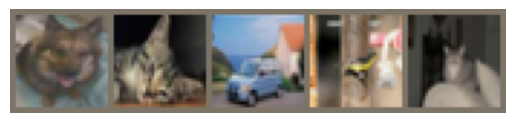

Canal 0


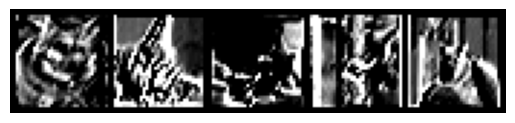

Canal 1


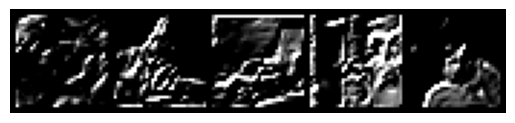

Canal 2


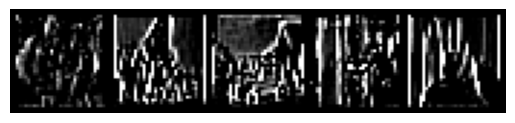

Canal 3


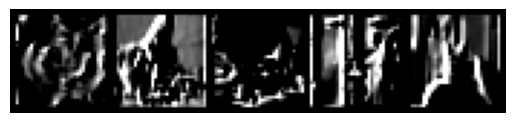

Canal 4


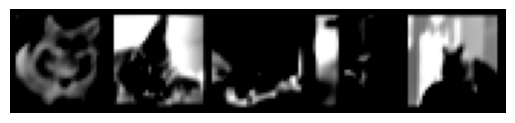

Canal 5


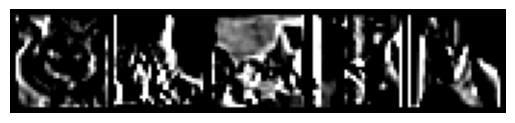

Canal 0


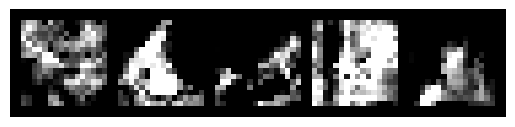

Canal 1


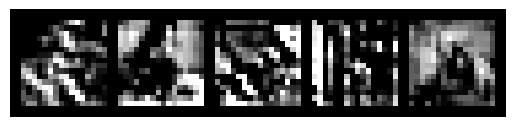

Canal 2


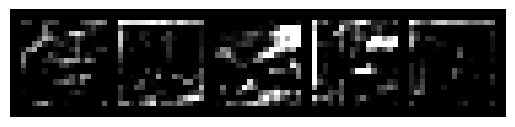

Canal 3


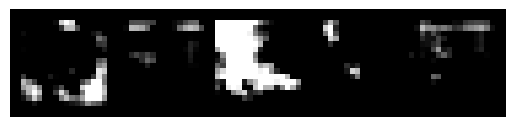

Canal 4


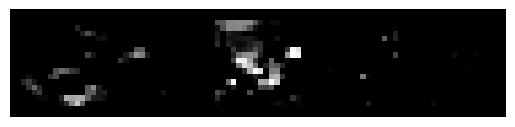

Canal 5


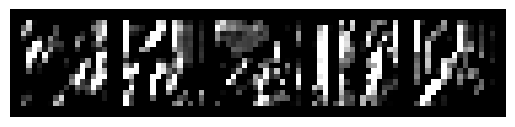

Canal 6


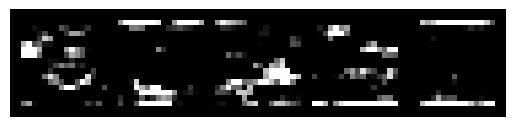

Canal 7


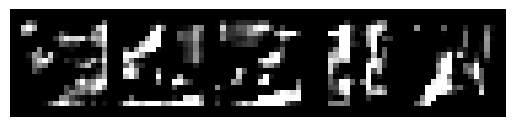

Canal 8


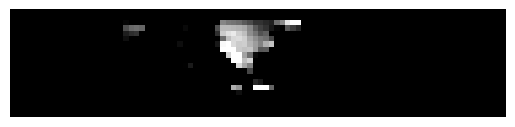

Canal 9


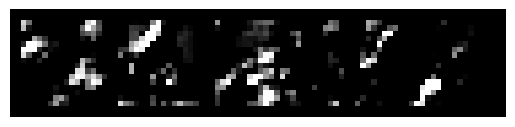

Canal 10


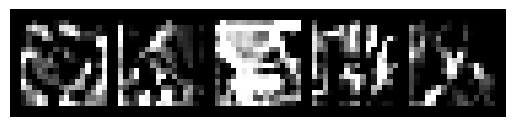

Canal 11


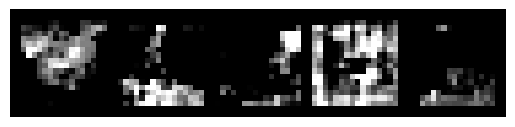

Canal 12


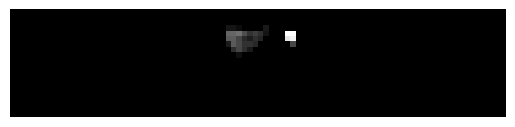

Canal 13


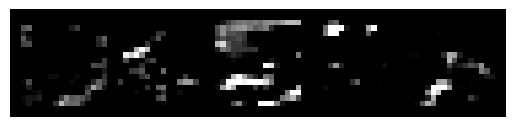

Canal 14


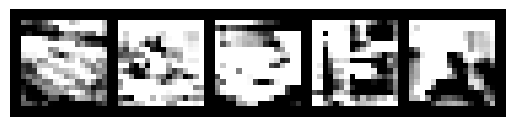

Canal 15


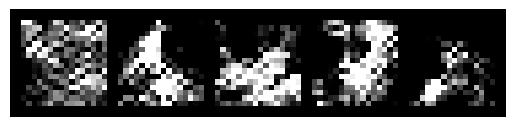

In [24]:
show_batch(
    torchvision.utils.make_grid(images_batch.to('cpu')),
)

for i in range(0, 6):
  print(f"Canal {i}")
  show_features(features_conv1, filter_index=i)

for i in range(0, 16):
  print(f"Canal {i}")
  show_features(features_conv2, filter_index=i)

#### 🧩 Proyección del espacio latente

El **espacio latente** es la representación interna que el modelo construye a partir de los datos de entrada.
En lugar de trabajar directamente con píxeles, la red transforma la información en un conjunto de características más compactas y significativas.

![Latent Space CNN](https://media.springernature.com/lw685/springer-static/image/chp%3A10.1007%2F978-981-16-3357-7_8/MediaObjects/512874_1_En_8_Fig1_HTML.png)

En una CNN, esta representación se obtiene después de las capas
convolucionales — una vez que la red ha extraído las features espaciales
de la imagen, se genera un vector compacto que resume toda esa información.
Dependiendo de la arquitectura, este vector puede obtenerse mediante
capas totalmente conectadas, un pooling global, o un token especial como
en los Transformers.

![Latent Visualization](https://www.baeldung.com/wp-content/uploads/sites/4/2022/03/1_latent-1024x307.png)

En este espacio, cada imagen es un punto.
Imágenes similares tienden a estar cerca, mientras que diferentes se separan.

El **espacio latente** no solo sirve para clasificar.
Una vez que el modelo transforma la imagen en esta representación, puede reutilizarse para distintos objetivos como **clasificación**, **regresión** o incluso **reconstrucción**.

Es decir, el modelo primero aprende una buena representación… y luego esa representación se adapta a la tarea que necesites.

In [25]:
model.eval()

all_features = []
all_labels = []

# 1. Extraemos representaciones latentes (antes de la capa final)
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # CNN
        x = model.feature_extractor(images)
        x = x.view(x.size(0), -1)

        # Pasamos por el MLP SIN la última capa (clasificación)
        x = model.mlp[:-2](x)

        # Guardamos
        all_features.append(x.cpu().numpy())
        all_labels.append(labels.numpy())

# Concatenamos todo en un solo array gigante
all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

all_features.shape, all_labels.shape

((10000, 254), (10000,))

##### 🧩 3D

In [26]:
umap_embeddings = umap.UMAP(n_components=3).fit_transform(all_features)
umap_embeddings.shape

(10000, 3)

In [27]:
plot_latent_space_3d(
    umap_embeddings,
    all_labels,
    classes
)

##### 🧩 2D

In [28]:
umap_embeddings_2d = umap.UMAP(n_components=2).fit_transform(all_features)
umap_embeddings_2d.shape

(10000, 2)

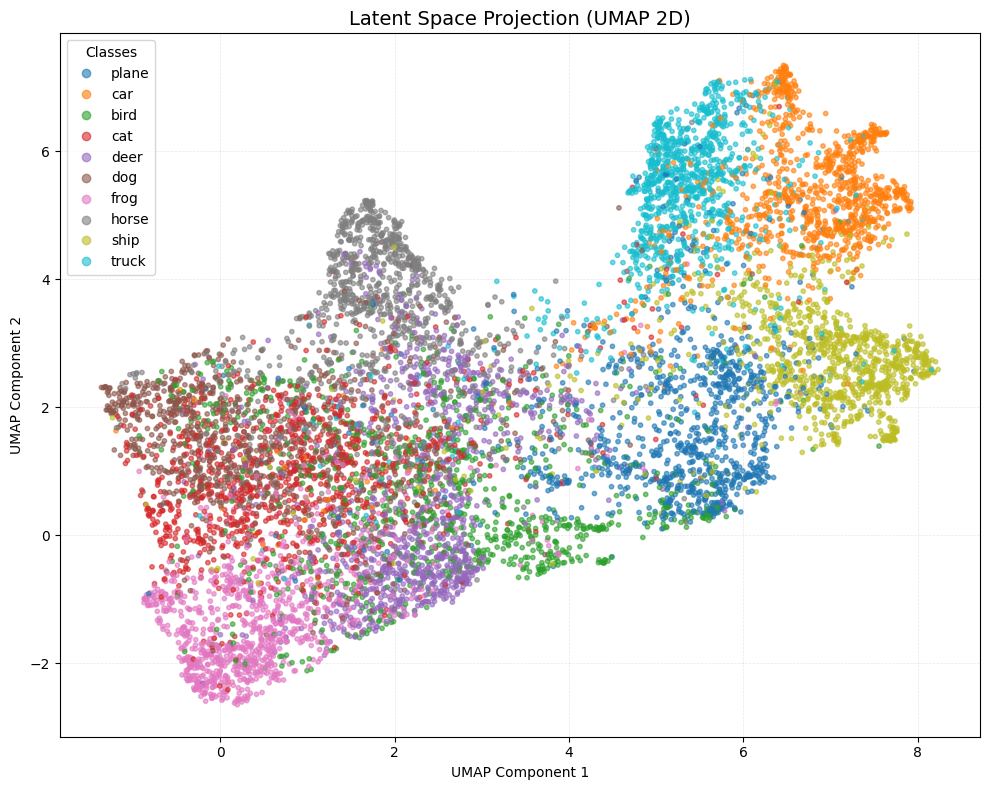

In [29]:
plot_latent_space_2d(
    umap_embeddings_2d,
    all_labels,
    classes
)